# RSA Compare: ResNet-50 vs. ViT-B/16 vs. CLIP
## CNN / Transformer / Vision-Language — THINGS-fMRI

---

**Basiert auf:** Kriegeskorte, Mur & Bandettini (2008). *Representational similarity analysis.* Frontiers in Systems Neuroscience 2:4.

**Datensatz:** Hebart et al. (2023). *THINGS-data.* eLife 12:e82580.

**Modelle:** ResNet-50, ViT-B/16, CLIP ViT-B/32 (Radford et al. 2021)

---


In [2]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 1 — Imports & Konfiguration
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import h5py
import torch
import torchvision.models as models
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Pfade ──────────────────────────────────────────────────────
RSA_DIR           = Path(r'C:\Users\nilsl\Desktop\Projekte\RSA')
DATENSATZ_DIR     = RSA_DIR / 'Datensatz'
H5_FILE           = DATENSATZ_DIR / 'sub-01_task-things_voxel-wise-responses.h5'
VOX_META          = DATENSATZ_DIR / 'sub-01_task-things_voxel-metadata.csv'
STIM_META         = DATENSATZ_DIR / 'sub-01_task-things_stimulus-metadata.csv'
THINGS_IMAGES_DIR = DATENSATZ_DIR / 'images_THINGS' / 'object_images'

# ── Konfiguration ──────────────────────────────────────────────
N_IMAGES  = 100
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROI_NAMES = ['V1', 'V2', 'V3', 'V4', 'LOC', 'IT']

print(f'Device: {DEVICE}')
for f in [H5_FILE, VOX_META, STIM_META, THINGS_IMAGES_DIR]:
    print(f"  {'✅' if f.exists() else '❌'} {f.name}")

Device: cpu
  ✅ sub-01_task-things_voxel-wise-responses.h5
  ✅ sub-01_task-things_voxel-metadata.csv
  ✅ sub-01_task-things_stimulus-metadata.csv
  ✅ object_images


In [3]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 2 — fMRI-Daten laden & RDMs berechnen
# ══════════════════════════════════════════════════════════════════

def compute_rdm(features: np.ndarray) -> np.ndarray:
    return squareform(pdist(features, metric='correlation'))

def compare_rdms(rdm_a, rdm_b):
    n   = rdm_a.shape[0]
    idx = np.triu_indices(n, k=1)
    rho, p = spearmanr(rdm_a[idx], rdm_b[idx])
    return rho, p

# ── Metadaten ─────────────────────────────────────────────────
vox_meta  = pd.read_csv(VOX_META,  sep=',')
stim_meta = pd.read_csv(STIM_META, sep=',')
print(f'vox_meta:  {vox_meta.shape}')
print(f'stim_meta: {stim_meta.shape}')

# ── ROI-Masken aus Binär-Spalten ──────────────────────────────
roi_masks = {}
roi_masks['V1']  = vox_meta['V1'].values.astype(bool)
roi_masks['V2']  = vox_meta['V2'].values.astype(bool)
roi_masks['V3']  = vox_meta['V3'].values.astype(bool)
roi_masks['V4']  = vox_meta['hV4'].values.astype(bool)
roi_masks['LOC'] = (vox_meta['lLOC'].values.astype(bool) |
                    vox_meta['rLOC'].values.astype(bool))
roi_masks['IT']  = vox_meta['IT'].values.astype(bool)

for roi, mask in roi_masks.items():
    print(f'  {roi:5}: {mask.sum():,} Voxel')

combined_mask     = np.zeros(len(vox_meta), dtype=bool)
for m in roi_masks.values():
    combined_mask |= m
roi_voxel_indices = np.where(combined_mask)[0]
global_to_local   = {int(g): l for l, g in enumerate(roi_voxel_indices)}

# ── HDF5 laden (nur ROI-Voxel) ────────────────────────────────
print('\nLade fMRI...')
with h5py.File(H5_FILE, 'r') as f:
    dset         = f['ResponseData/block0_values']
    print(f'Dataset shape (auf Disk): {dset.shape}')
    roi_data_raw = dset[roi_voxel_indices, :].astype(np.float32)

responses_all = roi_data_raw.T
responses_all = (responses_all - responses_all.mean(axis=0)) / \
                (responses_all.std(axis=0) + 1e-8)

assert responses_all.shape[0] == len(stim_meta), \
    f"Mismatch: {responses_all.shape[0]} vs {len(stim_meta)}"
print(f'responses_all: {responses_all.shape}')

# ── Test-Stimuli auswählen (viele Repetitionen → gutes SNR) ───
stim_meta_test = stim_meta[stim_meta['trial_type'] == 'test'].copy()

seen, stim_order = set(), []
for s in stim_meta_test['stimulus']:
    if s not in seen:
        seen.add(s)
        stim_order.append(s)
stim_order = stim_order[:N_IMAGES]

reps = stim_meta_test.groupby('stimulus').size()
print(f'Test-Stimuli: {len(stim_order)}  |  Reps: min={reps.min()} max={reps.max()} mean={reps.mean():.1f}')

stim_responses, category_labels = [], []
for stim in tqdm(stim_order, desc='Mitteln'):
    idx = stim_meta_test.index[stim_meta_test['stimulus'] == stim].tolist()
    stim_responses.append(responses_all[idx].mean(axis=0))
    category_labels.append(stim_meta_test.loc[idx[0], 'concept'])

responses = np.array(stim_responses)
print(f'Gemittelt: {responses.shape}')

# ── fMRI-RDMs ─────────────────────────────────────────────────
fmri_rdms = {}
for roi in tqdm(ROI_NAMES, desc='fMRI RDMs'):
    g_idx = np.where(roi_masks[roi])[0]
    l_idx = np.array([global_to_local[int(g)] for g in g_idx
                      if int(g) in global_to_local])
    fmri_rdms[roi] = compute_rdm(responses[:, l_idx])

print('\nfMRI-RDMs:')
for roi in ROI_NAMES:
    n   = fmri_rdms[roi].shape[0]
    tri = fmri_rdms[roi][np.triu_indices(n, k=1)]
    print(f'  {roi:5}: mean={tri.mean():.4f}  std={tri.std():.4f}')
print('✅ fMRI fertig')

vox_meta:  (211339, 222)
stim_meta: (9840, 7)
  V1   : 1,049 Voxel
  V2   : 774 Voxel
  V3   : 762 Voxel
  V4   : 613 Voxel
  LOC  : 2,700 Voxel
  IT   : 4,145 Voxel

Lade fMRI...
Dataset shape (auf Disk): (211339, 9840)
responses_all: (9840, 8406)
Test-Stimuli: 100  |  Reps: min=12 max=12 mean=12.0


Mitteln: 100%|██████████| 100/100 [00:00<00:00, 307.42it/s]


Gemittelt: (100, 8406)


fMRI RDMs: 100%|██████████| 6/6 [00:00<00:00, 149.05it/s]


fMRI-RDMs:
  V1   : mean=1.0020  std=0.1339
  V2   : mean=1.0003  std=0.1184
  V3   : mean=1.0027  std=0.1099
  V4   : mean=1.0008  std=0.0905
  LOC  : mean=1.0000  std=0.0852
  IT   : mean=1.0009  std=0.0746
✅ fMRI fertig


In [4]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 3 — Bilder laden (einmalig für beide Modelle)
# ══════════════════════════════════════════════════════════════════

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

image_tensors_list  = []
category_labels_cnn = []
missing = 0

for stim_name in tqdm(stim_order, desc='Bilder laden'):
    concept  = stim_name.split('_')[0]
    img_path = THINGS_IMAGES_DIR / concept / stim_name
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
    else:
        img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        missing += 1
    image_tensors_list.append(preprocess(img))
    category_labels_cnn.append(concept)

print(f'Bilder: {len(image_tensors_list)}  fehlend: {missing}')
image_tensors = torch.stack(image_tensors_list)
print('✅ Bilder bereit')

Bilder laden: 100%|██████████| 100/100 [00:00<00:00, 101.43it/s]

Bilder: 100  fehlend: 5
✅ Bilder bereit


In [5]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 4 — ResNet-50 Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════

resnet       = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.eval().to(DEVICE)

resnet_layers   = ['layer1', 'layer2', 'layer3', 'layer4']
resnet_raw      = {}
resnet_features = {l: [] for l in resnet_layers}

def make_hook(name, store):
    def hook(module, input, output):
        store[name] = output.mean(dim=[2, 3]).detach().cpu()
    return hook

hooks = [
    resnet.layer1.register_forward_hook(make_hook('layer1', resnet_raw)),
    resnet.layer2.register_forward_hook(make_hook('layer2', resnet_raw)),
    resnet.layer3.register_forward_hook(make_hook('layer3', resnet_raw)),
    resnet.layer4.register_forward_hook(make_hook('layer4', resnet_raw)),
]

with torch.no_grad():
    for start in tqdm(range(0, len(image_tensors), 32), desc='ResNet-50'):
        batch = image_tensors[start:start+32].to(DEVICE)
        _ = resnet(batch)
        for l in resnet_layers:
            resnet_features[l].append(resnet_raw[l].numpy())

for h in hooks:
    h.remove()

for l in resnet_layers:
    resnet_features[l] = np.concatenate(resnet_features[l], axis=0)

resnet_rdms = {l: compute_rdm(resnet_features[l]) for l in resnet_layers}

print('ResNet-50 RDMs:')
for l in resnet_layers:
    n = resnet_rdms[l].shape[0]
    print(f'  {l}: {resnet_features[l].shape}  mean_dist={resnet_rdms[l][np.triu_indices(n,k=1)].mean():.3f}')
print('✅ ResNet-50 fertig')

ResNet-50: 100%|██████████| 4/4 [00:06<00:00,  1.69s/it]

ResNet-50 RDMs:
  layer1: (100, 256)  mean_dist=0.271
  layer2: (100, 512)  mean_dist=0.391
  layer3: (100, 1024)  mean_dist=0.536
  layer4: (100, 2048)  mean_dist=0.942
✅ ResNet-50 fertig


In [6]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 5 — ViT-B/16 Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════

vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.eval().to(DEVICE)

# Block 3, 6, 9, 12 → früh bis spät
vit_layer_indices = {'block3': 2, 'block6': 5, 'block9': 8, 'block12': 11}
vit_raw           = {}
vit_features      = {k: [] for k in vit_layer_indices}

# Zelle 5 — make_vit_hook anpassen:
def make_vit_hook(name, store):
    def hook(module, input, output):
        # Patch-Token Mittelwert statt CLS-Token
        store[name] = output[:, 1:, :].mean(dim=1).detach().cpu()
    return hook

vit_hooks = []
for name, idx in vit_layer_indices.items():
    h = vit.encoder.layers[idx].register_forward_hook(
        make_vit_hook(name, vit_raw))
    vit_hooks.append(h)

with torch.no_grad():
    for start in tqdm(range(0, len(image_tensors), 32), desc='ViT-B/16'):
        batch = image_tensors[start:start+32].to(DEVICE)
        _ = vit(batch)
        for name in vit_layer_indices:
            vit_features[name].append(vit_raw[name].numpy())

for h in vit_hooks:
    h.remove()

for name in vit_layer_indices:
    vit_features[name] = np.concatenate(vit_features[name], axis=0)

vit_rdms = {name: compute_rdm(vit_features[name]) for name in vit_layer_indices}

print('ViT-B/16 RDMs:')
for name in vit_layer_indices:
    n = vit_rdms[name].shape[0]
    print(f'  {name}: {vit_features[name].shape}  mean_dist={vit_rdms[name][np.triu_indices(n,k=1)].mean():.3f}')
print('✅ ViT-B/16 fertig')

ViT-B/16: 100%|██████████| 4/4 [00:34<00:00,  8.64s/it]

ViT-B/16 RDMs:
  block3: (100, 768)  mean_dist=0.668
  block6: (100, 768)  mean_dist=0.680
  block9: (100, 768)  mean_dist=0.623
  block12: (100, 768)  mean_dist=0.225
✅ ViT-B/16 fertig


In [7]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 5b — CLIP Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════
# CLIP (Radford et al. 2021) — OpenAI
# Training: 400M Bild-Text-Paare (kontrastiv)
# Hypothese: Sprachliches Training verbessert Korrelation mit IT

try:
    import clip
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'clip-anytorch',
                    '--quiet'], check=True)
    import clip

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()

# CLIP braucht eigene Preprocessing-Pipeline
clip_tensors_list = []
for stim_name in tqdm(stim_order, desc='CLIP Bilder laden'):
    concept  = stim_name.split('_')[0]
    img_path = THINGS_IMAGES_DIR / concept / stim_name
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
    else:
        img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    clip_tensors_list.append(clip_preprocess(img))

clip_tensors = torch.stack(clip_tensors_list)
print(f'CLIP-Bilder bereit: {clip_tensors.shape}')

# Transformer-Blöcke: 3, 6, 9, 12 (ViT-B/32 hat 12 Blöcke)
clip_layer_indices = {'clip_block3': 2, 'clip_block6': 5,
                      'clip_block9': 8, 'clip_block12': 11}
clip_raw      = {}
clip_features = {k: [] for k in clip_layer_indices}

def make_clip_hook(name, store):
    def hook(module, input, output):
        # output shape: [seq_len, batch, dim] — CLIP nutzt seq-first
        # Patch-Tokens = Index 1: → mean über Patch-Dimension
        if output.dim() == 3:
            store[name] = output[1:, :, :].mean(dim=0).detach().cpu()
        else:
            store[name] = output.detach().cpu()
    return hook

clip_hooks = []
for name, idx in clip_layer_indices.items():
    h = clip_model.visual.transformer.resblocks[idx].register_forward_hook(
        make_clip_hook(name, clip_raw))
    clip_hooks.append(h)

with torch.no_grad():
    for start in tqdm(range(0, len(clip_tensors), 32), desc='CLIP'):
        batch = clip_tensors[start:start+32].to(DEVICE)
        _ = clip_model.encode_image(batch)
        for name in clip_layer_indices:
            clip_features[name].append(clip_raw[name].numpy())

for h in clip_hooks:
    h.remove()

for name in clip_layer_indices:
    clip_features[name] = np.concatenate(clip_features[name], axis=0)

clip_rdms = {name: compute_rdm(clip_features[name])
             for name in clip_layer_indices}

print('CLIP RDMs:')
for name in clip_layer_indices:
    n = clip_rdms[name].shape[0]
    print(f'  {name}: {clip_features[name].shape}  '
          f'mean_dist={clip_rdms[name][np.triu_indices(n,k=1)].mean():.3f}')
print('✅ CLIP fertig')


CLIP Bilder laden: 100%|██████████| 100/100 [00:01<00:00, 59.60it/s]


CLIP-Bilder bereit: torch.Size([100, 3, 224, 224])


CLIP: 100%|██████████| 4/4 [00:08<00:00,  2.04s/it]

CLIP RDMs:
  clip_block3: (100, 768)  mean_dist=0.438
  clip_block6: (100, 768)  mean_dist=0.632
  clip_block9: (100, 768)  mean_dist=0.659
  clip_block12: (100, 768)  mean_dist=0.161
✅ CLIP fertig


In [8]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 6 — RSA: ResNet-50 / ViT-B/16 / CLIP vs. Gehirn
# ══════════════════════════════════════════════════════════════════

n_rois          = len(ROI_NAMES)
vit_layer_names  = list(vit_layer_indices.keys())
clip_layer_names = list(clip_layer_indices.keys())

resnet_rho = np.zeros((len(resnet_layers), n_rois))
resnet_p   = np.zeros_like(resnet_rho)
vit_rho    = np.zeros((len(vit_layer_names), n_rois))
vit_p      = np.zeros_like(vit_rho)
clip_rho   = np.zeros((len(clip_layer_names), n_rois))
clip_p     = np.zeros_like(clip_rho)

for i, layer in enumerate(resnet_layers):
    for j, roi in enumerate(ROI_NAMES):
        resnet_rho[i,j], resnet_p[i,j] = compare_rdms(resnet_rdms[layer], fmri_rdms[roi])

for i, name in enumerate(vit_layer_names):
    for j, roi in enumerate(ROI_NAMES):
        vit_rho[i,j], vit_p[i,j] = compare_rdms(vit_rdms[name], fmri_rdms[roi])

for i, name in enumerate(clip_layer_names):
    for j, roi in enumerate(ROI_NAMES):
        clip_rho[i,j], clip_p[i,j] = compare_rdms(clip_rdms[name], fmri_rdms[roi])

for label, rho_mat, layer_names, p_mat in [
    ('ResNet-50', resnet_rho, resnet_layers, resnet_p),
    ('ViT-B/16',  vit_rho,   vit_layer_names, vit_p),
    ('CLIP',      clip_rho,  clip_layer_names, clip_p),
]:
    print(f'{label} (Spearman ρ):')
    print(f'  {"":12}', '  '.join(f'{r:>6}' for r in ROI_NAMES))
    for i, lname in enumerate(layer_names):
        row = f'  {lname:12}'
        for j in range(n_rois):
            sig = '*' if p_mat[i,j] < 0.05 else ' '
            row += f'  {rho_mat[i,j]:+.3f}{sig}'
        print(row)
    print()
print('Signifikanz: * p<0.05')


ResNet-50 (Spearman ρ):
                   V1      V2      V3      V4     LOC      IT
  layer1        +0.135*  +0.113*  +0.089*  +0.069*  +0.009   +0.017 
  layer2        +0.160*  +0.126*  +0.099*  +0.104*  +0.011   +0.033*
  layer3        +0.123*  +0.098*  +0.086*  +0.121*  +0.048*  +0.082*
  layer4        +0.080*  +0.054*  +0.053*  +0.086*  +0.116*  +0.136*

ViT-B/16 (Spearman ρ):
                   V1      V2      V3      V4     LOC      IT
  block3        +0.201*  +0.163*  +0.125*  +0.127*  +0.026   +0.052*
  block6        +0.155*  +0.114*  +0.096*  +0.125*  +0.054*  +0.080*
  block9        +0.099*  +0.066*  +0.055*  +0.093*  +0.064*  +0.086*
  block12       +0.067*  +0.066*  +0.044*  +0.070*  +0.022   +0.056*

CLIP (Spearman ρ):
                   V1      V2      V3      V4     LOC      IT
  clip_block3   +0.157*  +0.131*  +0.108*  +0.094*  +0.008   +0.029*
  clip_block6   +0.160*  +0.121*  +0.109*  +0.124*  +0.046*  +0.085*
  clip_block9   +0.146*  +0.089*  +0.083*  +0.105*  +0.0

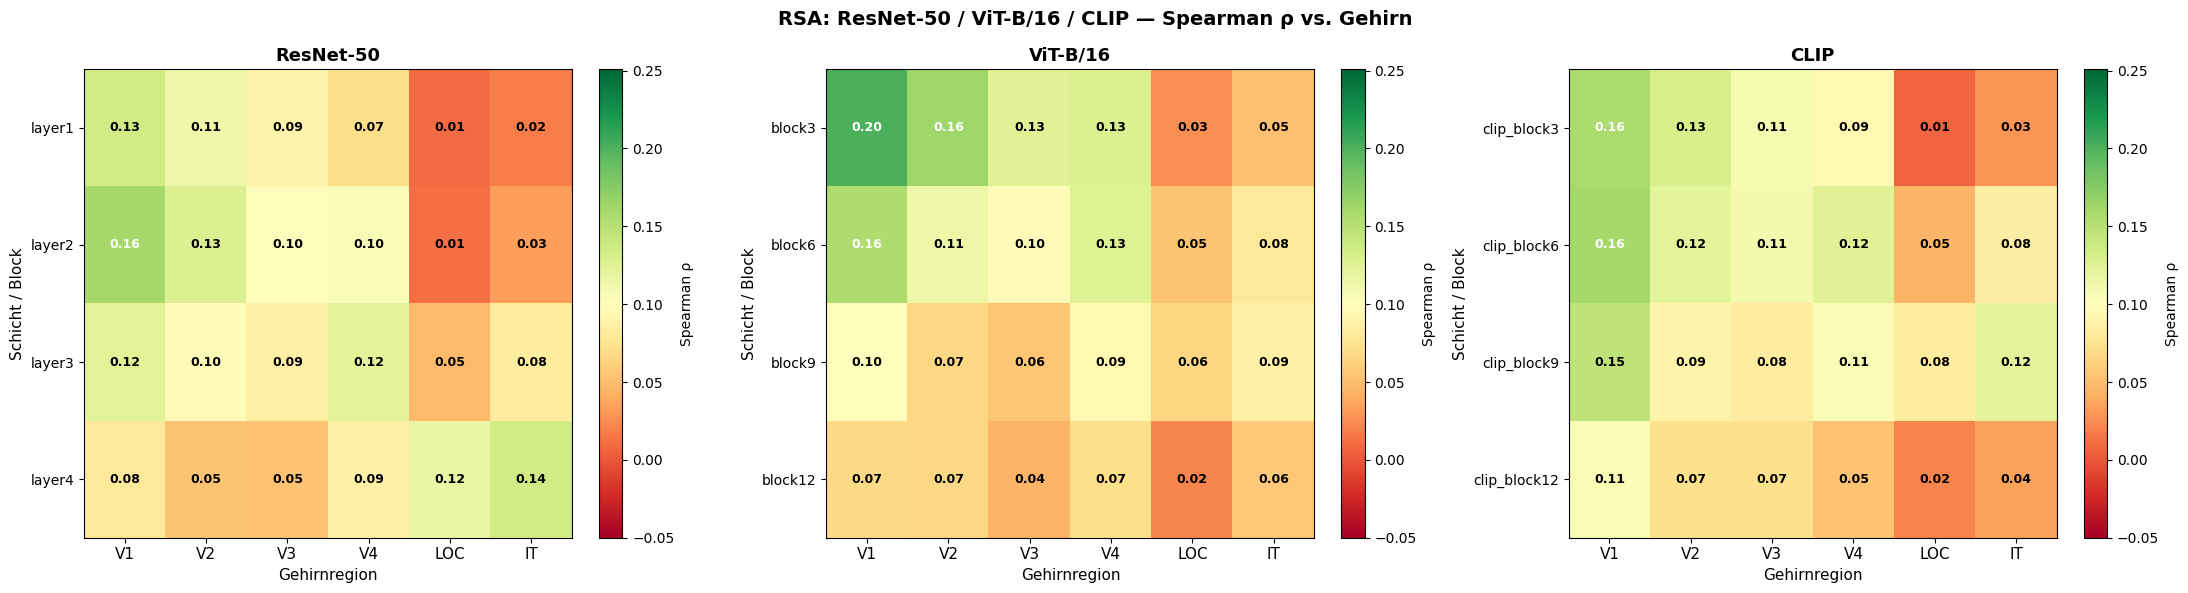

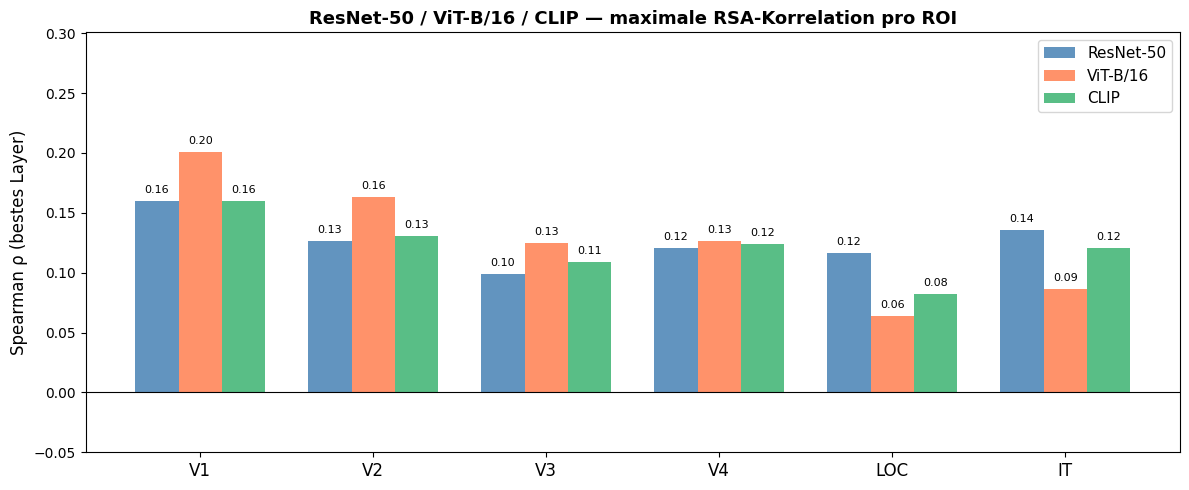

✅ Gespeichert


In [9]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 7 — Visualisierung: 3 Modelle
# ══════════════════════════════════════════════════════════════════

vmax = max(resnet_rho.max(), vit_rho.max(), clip_rho.max()) + 0.05

# ── Heatmap: 3 Panels ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('RSA: ResNet-50 / ViT-B/16 / CLIP — Spearman ρ vs. Gehirn',
             fontsize=14, fontweight='bold')

all_models = [
    ('ResNet-50', resnet_rho, resnet_layers),
    ('ViT-B/16',  vit_rho,   vit_layer_names),
    ('CLIP',      clip_rho,  clip_layer_names),
]

for ax, (title, rho_mat, layer_names) in zip(axes, all_models):
    im = ax.imshow(rho_mat, cmap='RdYlGn', vmin=-0.05, vmax=vmax, aspect='auto')
    ax.set_xticks(range(n_rois))
    ax.set_xticklabels(ROI_NAMES, fontsize=11)
    ax.set_yticks(range(len(layer_names)))
    ax.set_yticklabels(layer_names, fontsize=10)
    ax.set_xlabel('Gehirnregion', fontsize=11)
    ax.set_ylabel('Schicht / Block', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i in range(len(layer_names)):
        for j in range(n_rois):
            col = 'white' if rho_mat[i,j] > vmax * 0.6 else 'black'
            ax.text(j, i, f'{rho_mat[i,j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color=col, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Spearman ρ', fraction=0.046)

plt.tight_layout()
plt.savefig(RSA_DIR / 'rsa_compare_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Balkendiagramm: bestes Layer pro ROI, 3 Modelle ──────────
fig, ax = plt.subplots(figsize=(12, 5))

resnet_best = resnet_rho.max(axis=0)
vit_best    = vit_rho.max(axis=0)
clip_best   = clip_rho.max(axis=0)

x = np.arange(n_rois)
w = 0.25

bars1 = ax.bar(x - w,    resnet_best, w, label='ResNet-50', color='steelblue', alpha=0.85)
bars2 = ax.bar(x,        vit_best,    w, label='ViT-B/16',  color='coral',     alpha=0.85)
bars3 = ax.bar(x + w,    clip_best,   w, label='CLIP',      color='mediumseagreen', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ROI_NAMES, fontsize=12)
ax.set_ylabel('Spearman ρ (bestes Layer)', fontsize=12)
ax.set_title('ResNet-50 / ViT-B/16 / CLIP — maximale RSA-Korrelation pro ROI',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-0.05, vmax + 0.05)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(RSA_DIR / 'rsa_compare_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gespeichert')


In [10]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 8 — Noise Ceiling (Split-Half, Spearman-Brown)
# ══════════════════════════════════════════════════════════════════

def rdm_noise_ceiling(roi_key, n_splits=100):
    g_idx = np.where(roi_masks[roi_key])[0]
    l_idx = np.array([global_to_local[int(g)] for g in g_idx
                      if int(g) in global_to_local])
    rhos = []
    for _ in range(n_splits):
        half_a, half_b = [], []
        for stim in stim_order:
            idx = stim_meta_test.index[stim_meta_test['stimulus'] == stim].tolist()
            np.random.shuffle(idx)
            mid = max(1, len(idx) // 2)
            half_a.append(responses_all[idx[:mid]].mean(axis=0))
            half_b.append(responses_all[idx[mid:]].mean(axis=0))
        rdm_a = compute_rdm(np.array(half_a)[:, l_idx])
        rdm_b = compute_rdm(np.array(half_b)[:, l_idx])
        n     = rdm_a.shape[0]
        tri   = np.triu_indices(n, k=1)
        rho, _ = spearmanr(rdm_a[tri], rdm_b[tri])
        rho_corrected = (2 * rho) / (1 + rho)  # Spearman-Brown
        rhos.append(rho_corrected)
    return np.mean(rhos)

print('RSA Noise Ceilings (Split-Half, Spearman-Brown korrigiert):')
print()
noise_ceilings = {}
for roi in ROI_NAMES:
    nc         = rdm_noise_ceiling(roi)
    noise_ceilings[roi] = nc
    r_rho      = resnet_rho[:, ROI_NAMES.index(roi)].max()
    v_rho      = vit_rho[:,   ROI_NAMES.index(roi)].max()
    c_rho      = clip_rho[:,  ROI_NAMES.index(roi)].max()
    print(f'  {roi:5}: NC={nc:.3f}  |  '
          f'ResNet {r_rho:.3f} ({r_rho/nc*100:.0f}%NC)  |  '
          f'ViT {v_rho:.3f} ({v_rho/nc*100:.0f}%NC)  |  '
          f'CLIP {c_rho:.3f} ({c_rho/nc*100:.0f}%NC)')
print('\n✅ Fertig')


RSA Noise Ceilings (Split-Half, Spearman-Brown korrigiert):

  V1   : NC=0.514  |  ResNet 0.160 (31%NC)  |  ViT 0.201 (39%NC)  |  CLIP 0.160 (31%NC)
  V2   : NC=0.449  |  ResNet 0.126 (28%NC)  |  ViT 0.163 (36%NC)  |  CLIP 0.131 (29%NC)
  V3   : NC=0.378  |  ResNet 0.099 (26%NC)  |  ViT 0.125 (33%NC)  |  CLIP 0.109 (29%NC)
  V4   : NC=0.232  |  ResNet 0.121 (52%NC)  |  ViT 0.127 (55%NC)  |  CLIP 0.124 (53%NC)
  LOC  : NC=0.398  |  ResNet 0.116 (29%NC)  |  ViT 0.064 (16%NC)  |  CLIP 0.083 (21%NC)
  IT   : NC=0.407  |  ResNet 0.136 (33%NC)  |  ViT 0.086 (21%NC)  |  CLIP 0.121 (30%NC)

✅ Fertig


In [11]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 9 — Interpretation
# ══════════════════════════════════════════════════════════════════

clip_layer_names_short = list(clip_layer_indices.keys())

print('=' * 78)
print('VERGLEICH: ResNet-50 / ViT-B/16 / CLIP')
print('=' * 78)
print()
print(f'  {"ROI":5} {"ResNet ρ":>10} {"Layer":>8} | '
      f'{"ViT ρ":>8} {"Block":>8} | '
      f'{"CLIP ρ":>8} {"Block":>10} | {"Gewinner":>12}')
print('─' * 78)

for j, roi in enumerate(ROI_NAMES):
    r_i   = resnet_rho[:, j].argmax()
    v_i   = vit_rho[:,   j].argmax()
    c_i   = clip_rho[:,  j].argmax()
    r_rho = resnet_rho[r_i, j]
    v_rho = vit_rho[v_i, j]
    c_rho = clip_rho[c_i, j]
    best  = max([(r_rho, 'ResNet-50'), (v_rho, 'ViT-B/16'), (c_rho, 'CLIP')])[1]
    print(f'  {roi:5} {r_rho:>10.3f} {resnet_layers[r_i]:>8} | '
          f'{v_rho:>8.3f} {vit_layer_names[v_i]:>8} | '
          f'{c_rho:>8.3f} {clip_layer_names_short[c_i]:>10} | '
          f'{best:>12}')

print()
print('Hypothese (Conwell et al. 2022 + eigene):')
print('  CLIP > ViT/ResNet für IT  (semantisches Training hilft)')
print('  ResNet ≈ ViT für V1–V3   (frühe Areale, texturbasiert)')
print()
print('ρ-Referenzwerte:')
print('  ρ > 0.40  sehr stark')
print('  ρ ~ 0.20  moderat (typisch single-subject RSA)')
print('  ρ < 0.05  kein bedeutsamer Zusammenhang')


VERGLEICH: ResNet-50 / ViT-B/16 / CLIP

  ROI     ResNet ρ    Layer |    ViT ρ    Block |   CLIP ρ      Block |     Gewinner
──────────────────────────────────────────────────────────────────────────────
  V1         0.160   layer2 |    0.201   block3 |    0.160 clip_block6 |     ViT-B/16
  V2         0.126   layer2 |    0.163   block3 |    0.131 clip_block3 |     ViT-B/16
  V3         0.099   layer2 |    0.125   block3 |    0.109 clip_block6 |     ViT-B/16
  V4         0.121   layer3 |    0.127   block3 |    0.124 clip_block6 |     ViT-B/16
  LOC        0.116   layer4 |    0.064   block9 |    0.083 clip_block9 |    ResNet-50
  IT         0.136   layer4 |    0.086   block9 |    0.121 clip_block9 |    ResNet-50

Hypothese (Conwell et al. 2022 + eigene):
  CLIP > ViT/ResNet für IT  (semantisches Training hilft)
  ResNet ≈ ViT für V1–V3   (frühe Areale, texturbasiert)

ρ-Referenzwerte:
  ρ > 0.40  sehr stark
  ρ ~ 0.20  moderat (typisch single-subject RSA)
  ρ < 0.05  kein bedeutsamer Zus